# Déction de Fraudes Financières — Dataset PaySim


## Modèles Baseline (`03_baseline_models`)

**Objectif :** Établir des réences supervisées solides avant les approches Deep Learning.

**Contexte (NB02) :**

| Donnée | Valeur |
|---|---|
| Train | 139 999 lignes — **181 fraudes** (0.1293%) |
| Val | 30 000 lignes — **38 fraudes** |
| Test | 30 001 lignes — **39 fraudes** |
| Ratio imbalance | **1 : 772** |
| class_weight[1] | **386.74** |
| Baseline métier | Recall=0.0039 · Precision=1.0 · F1=0.0077 |

**4 modèles entraené:**
1. `LR_balanced`  — Logistic Regression + class_weight='balanced'
2. `LR_smote`     — Logistic Regression + donnéE
3. `RF_balanced`  — Random Forest + class_weight='balanced'
4. `RF_smote`     — Random Forest + donnés SMOTE

**Métriques prioritaires :** Recall · PR-AUC · F1 (pas l'accuracy)

---
### Plan
1. Configuration & Imports
2. Chargement des données préparées
3. Logistic Regression — LR_balanced
4. Logistic Regression — LR_smote
5. Random Forest — RF_balanced
6. Random Forest — RF_smote
7. Analyse du seuil de décision
8. Comparaison des 4 modèles
9. Feature Importances
10. Sauvegarde des modèles et rapport
11. Synthèse


---
### 1. Configuration & Imports


In [1]:
from pathlib import Path
import sys, importlib, warnings, json, time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

warnings.filterwarnings('ignore')
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12,
                     'axes.titleweight': 'bold'})


In [2]:
project_root = Path('.').resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

PROCESSED_DIR = project_root / 'data' / 'processed'
MODELS_DIR    = project_root / 'outputs' / 'models'
FIGURES_DIR   = project_root / 'outputs' / 'figures'
REPORTS_DIR   = project_root / 'outputs' / 'reports'

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root  : {project_root}')
print(f'Processed dir : {PROCESSED_DIR}')
print(f'Models dir    : {MODELS_DIR}')


Project root  : C:\Users\lenovo\Desktop\anomaly_detection_project
Processed dir : C:\Users\lenovo\Desktop\anomaly_detection_project\data\processed
Models dir    : C:\Users\lenovo\Desktop\anomaly_detection_project\outputs\models


In [3]:
# Baseline constants
RANDOM_STATE = 42

# Baseline metrics loaded from report when available
from src.utils.baseline_config import load_baseline_metrics
_baseline = load_baseline_metrics(MODELS_DIR / 'baseline_report.json')
BASELINE_RECALL, BASELINE_PRECISION, BASELINE_F1 = _baseline['recall'], _baseline['precision'], _baseline['f1']

print(f'Baseline isFlaggedFraud :')
print(f'  Recall    : {BASELINE_RECALL}')
print(f'  Precision : {BASELINE_PRECISION}')
print(f'  F1-Score  : {BASELINE_F1}')
print(f'  -> Objectif : Recall > {BASELINE_RECALL}  et  F1 > {BASELINE_F1}')


Baseline isFlaggedFraud :
  Recall    : 0.0039
  Precision : 1.0
  F1-Score  : 0.0077
  -> Objectif : Recall > 0.0039  et  F1 > 0.0077


In [4]:
import src.models.ml_models as ml_models_module
import src.utils.evaluator as evaluator_module
import src.visualization.model_plots as model_plots_module
importlib.reload(ml_models_module)
importlib.reload(evaluator_module)
importlib.reload(model_plots_module)

from src.models.ml_models import FraudLogisticRegression, FraudRandomForest
from src.utils.evaluator import compute_fraud_metrics, find_optimal_threshold, print_metrics_report, compare_models
from src.visualization.model_plots import (
    plot_pr_curves, plot_roc_curves, plot_confusion_matrices,
    plot_feature_importances, plot_threshold_analysis, plot_model_comparison
)
print('Modules src chargés.')


Modules src chargés.


---
### 2. Chargement des données préparées

Chargement depuis `data/processed/` (produit par NB02).
Les données sont déjÃ  scalées et prÃªtes —une transformation supplémentaire.


In [5]:
# — Chargement features.json et class_weights.json —
with open(MODELS_DIR / 'features.json', encoding='utf-8') as f:
    meta = json.load(f)
with open(MODELS_DIR / 'class_weights.json', encoding='utf-8') as f:
    class_weights_raw = json.load(f)

FEATURE_COLS  = meta['all_features']
TARGET        = meta['target']
CLASS_WEIGHTS = {int(k): float(v) for k, v in class_weights_raw.items()}

print(f'Features ({len(FEATURE_COLS)}) : {FEATURE_COLS}')
print(f'Target              : {TARGET}')
print(f'class_weights       : {CLASS_WEIGHTS}')


Features (14) : ['step', 'hour', 'day', 'week', 'high_risk_hour', 'is_transfer_or_cashout', 'balance_diff_orig', 'dest_zero_balance', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER', 'log_amount']
Target              : isFraud
class_weights       : {0: 0.5006472700224578, 1: 386.73756906077347}


In [6]:
# — Chargement des splits (NPY -> DataFrame) —
def load_split(prefix):
    x_path = PROCESSED_DIR / f'X_{prefix}.npy'
    y_path = PROCESSED_DIR / f'y_{prefix}.npy'

    # Certains artefacts .npy historiques sont en dtype=object.
    X_arr = np.load(x_path, allow_pickle=True)
    y_arr = np.load(y_path, allow_pickle=True)

    if X_arr.dtype == object:
        X_arr = X_arr.astype(np.float32)
    if y_arr.dtype == object:
        y_arr = y_arr.astype(np.int64)

    if X_arr.shape[1] != len(FEATURE_COLS):
        raise ValueError(
            f"Mismatch features: X_{prefix}.npy has {X_arr.shape[1]} cols, "
            f"but features.json defines {len(FEATURE_COLS)}"
        )

    X = pd.DataFrame(X_arr, columns=FEATURE_COLS)
    y = pd.Series(np.asarray(y_arr).ravel().astype(int), name=TARGET)
    return X, y

X_train, y_train = load_split('train')
X_val,   y_val   = load_split('val')
X_test,  y_test  = load_split('test')
X_smote, y_smote = load_split('train_smote')

print('Datasets charges :')
print(f'  Train         : {X_train.shape}  fraudes={int(y_train.sum())}  ({y_train.mean()*100:.4f}%)')
print(f'  Val           : {X_val.shape}    fraudes={int(y_val.sum())}')
print(f'  Test          : {X_test.shape}   fraudes={int(y_test.sum())}')
print(f'  Train SMOTE   : {X_smote.shape}  fraudes={int(y_smote.sum())}  ({y_smote.mean()*100:.4f}%)')
print('\nDonnees chargees avec succes (compatibilite NPY).')


Datasets charges :
  Train         : (139999, 14)  fraudes=181  (0.1293%)
  Val           : (30000, 14)    fraudes=38
  Test          : (30001, 14)   fraudes=39
  Train SMOTE   : (153799, 14)  fraudes=13981  (9.0904%)

Donnees chargees avec succes (compatibilite NPY).


---
### 3. Logistic Regression —_balanced`

**Stratégie :** `class_weight='balanced'` —énalise les erreurs sur les fraudes
d'un facteur **386.74Ã—** sans modifier les données d'entraenement.

**Régularisation :** C=0.1 (forte) —daptéu petit nombre de fraudes (181).


In [7]:
lr_balanced = FraudLogisticRegression(
    C=0.1,
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
)
lr_balanced.fit(X_train, y_train)
print(lr_balanced.summary())


FraudLogisticRegression
  C=0.1  solver=lbfgs
  class_weight=balanced
  max_iter=1000
  train_time=0.53s
  n_features=14


In [8]:
# — Évaluation sur Val (pour tuning) et Test (réultat final) —
lr_bal_score_val  = lr_balanced.predict_proba(X_val)
lr_bal_score_test = lr_balanced.predict_proba(X_test)

lr_bal_pred_val  = lr_balanced.predict(X_val,  threshold=0.5)
lr_bal_pred_test = lr_balanced.predict(X_test, threshold=0.5)

metrics_lr_bal_val  = compute_fraud_metrics(
    y_val, lr_bal_pred_val, lr_bal_score_val, threshold=0.5, model_name='LR_balanced (val)')
metrics_lr_bal_test = compute_fraud_metrics(
    y_test, lr_bal_pred_test, lr_bal_score_test, threshold=0.5, model_name='LR_balanced')

print('--- VALIDATION ---')
print_metrics_report(metrics_lr_bal_val, BASELINE_RECALL, BASELINE_F1)
print('\n--- TEST ---')
print_metrics_report(metrics_lr_bal_test, BASELINE_RECALL, BASELINE_F1)


--- VALIDATION ---
  LR_balanced (val)               seuil=0.50
  Recall    : 0.9737  ✅  (baseline 0.0039)
  Precision : 0.0391
  F1-Score  : 0.0752  ✅  (baseline 0.0077)
  Accuracy  : 0.9697
  PR-AUC    : 0.6379
  ROC-AUC   : 0.9950
----------------------------------------------------------
  Matrice de confusion :
    TP=    37   FN=     1
    FP=   909   TN=29,053

--- TEST ---
  LR_balanced                     seuil=0.50
  Recall    : 0.9487  ✅  (baseline 0.0039)
  Precision : 0.0420
  F1-Score  : 0.0805  ✅  (baseline 0.0077)
  Accuracy  : 0.9718
  PR-AUC    : 0.7044
  ROC-AUC   : 0.9961
----------------------------------------------------------
  Matrice de confusion :
    TP=    37   FN=     2
    FP=   843   TN=29,119


---
### 4. Logistic Regression —LR_smote`

**Straté:** Entraenement sur `X_train_smote` (ratio 1:10, 13 981 fraudes
dont 13 800 synthéques). Pas de `class_weight` car le rÃéchantillonnage
gère déle dééuilibre.

L'éluation reste sur **Val/Test originaux** (1:772) —ndispensable pour
mesurer les performances dans des conditions réstes.


In [9]:
lr_smote = FraudLogisticRegression(
    C=0.1,
    max_iter=1000,
    class_weight=None,   # SMOTE gère le déquilibre
    random_state=RANDOM_STATE,
)
lr_smote.fit(X_smote, y_smote)
print(lr_smote.summary())


FraudLogisticRegression
  C=0.1  solver=lbfgs
  class_weight=None
  max_iter=1000
  train_time=0.53s
  n_features=14


In [10]:
lr_smote_score_val  = lr_smote.predict_proba(X_val)
lr_smote_score_test = lr_smote.predict_proba(X_test)

lr_smote_pred_val  = lr_smote.predict(X_val,  threshold=0.5)
lr_smote_pred_test = lr_smote.predict(X_test, threshold=0.5)

metrics_lr_smote_val  = compute_fraud_metrics(
    y_val, lr_smote_pred_val, lr_smote_score_val, threshold=0.5, model_name='LR_smote (val)')
metrics_lr_smote_test = compute_fraud_metrics(
    y_test, lr_smote_pred_test, lr_smote_score_test, threshold=0.5, model_name='LR_smote')

print('--- VALIDATION ---')
print_metrics_report(metrics_lr_smote_val, BASELINE_RECALL, BASELINE_F1)
print('\n--- TEST ---')
print_metrics_report(metrics_lr_smote_test, BASELINE_RECALL, BASELINE_F1)


--- VALIDATION ---
  LR_smote (val)                  seuil=0.50
  Recall    : 0.8158  ✅  (baseline 0.0039)
  Precision : 0.1890
  F1-Score  : 0.3069  ✅  (baseline 0.0077)
  Accuracy  : 0.9953
  PR-AUC    : 0.6565
  ROC-AUC   : 0.9924
----------------------------------------------------------
  Matrice de confusion :
    TP=    31   FN=     7
    FP=   133   TN=29,829

--- TEST ---
  LR_smote                        seuil=0.50
  Recall    : 0.7692  ✅  (baseline 0.0039)
  Precision : 0.2113
  F1-Score  : 0.3315  ✅  (baseline 0.0077)
  Accuracy  : 0.9960
  PR-AUC    : 0.7393
  ROC-AUC   : 0.9949
----------------------------------------------------------
  Matrice de confusion :
    TP=    30   FN=     9
    FP=   112   TN=29,850


---
### 5. Random Forest —RF_balanced`

**Stratégie :** `class_weight='balanced'` + `max_depth=10` pour limiter
l'overfitting. Le RF peut capturer des interactions non-linéaires entre
`balance_diff_orig`, `is_transfer_or_cashout` et `dest_zero_balance`
que la régression logistique ne peut pas apprendre.


In [11]:
rf_balanced = FraudRandomForest(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
)
rf_balanced.fit(X_train, y_train)
print(rf_balanced.summary())


FraudRandomForest
  n_estimators=300
  max_depth=10
  min_samples_leaf=5
  class_weight=balanced
  train_time=5.99s
  n_features=14


In [12]:
rf_bal_score_val  = rf_balanced.predict_proba(X_val)
rf_bal_score_test = rf_balanced.predict_proba(X_test)

rf_bal_pred_val  = rf_balanced.predict(X_val,  threshold=0.5)
rf_bal_pred_test = rf_balanced.predict(X_test, threshold=0.5)

metrics_rf_bal_val  = compute_fraud_metrics(
    y_val, rf_bal_pred_val, rf_bal_score_val, threshold=0.5, model_name='RF_balanced (val)')
metrics_rf_bal_test = compute_fraud_metrics(
    y_test, rf_bal_pred_test, rf_bal_score_test, threshold=0.5, model_name='RF_balanced')

print('--- VALIDATION ---')
print_metrics_report(metrics_rf_bal_val, BASELINE_RECALL, BASELINE_F1)
print('\n--- TEST ---')
print_metrics_report(metrics_rf_bal_test, BASELINE_RECALL, BASELINE_F1)


--- VALIDATION ---
  RF_balanced (val)               seuil=0.50
  Recall    : 0.8158  ✅  (baseline 0.0039)
  Precision : 0.3069
  F1-Score  : 0.4460  ✅  (baseline 0.0077)
  Accuracy  : 0.9974
  PR-AUC    : 0.7570
  ROC-AUC   : 0.9962
----------------------------------------------------------
  Matrice de confusion :
    TP=    31   FN=     7
    FP=    70   TN=29,892

--- TEST ---
  RF_balanced                     seuil=0.50
  Recall    : 0.7949  ✅  (baseline 0.0039)
  Precision : 0.3333
  F1-Score  : 0.4697  ✅  (baseline 0.0077)
  Accuracy  : 0.9977
  PR-AUC    : 0.7794
  ROC-AUC   : 0.9922
----------------------------------------------------------
  Matrice de confusion :
    TP=    31   FN=     8
    FP=    62   TN=29,900


---
### 6. Random Forest —RF_smote`

**Stratégie :** Entrainement sur SMOTE sans class_weight.
Le RF + SMOTE est souvent la combinaison la plus performante pour
les datasets très déséquilibrés.


In [13]:
rf_smote = FraudRandomForest(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight=None,
    random_state=RANDOM_STATE,
)
rf_smote.fit(X_smote, y_smote)
print(rf_smote.summary())


FraudRandomForest
  n_estimators=300
  max_depth=10
  min_samples_leaf=5
  class_weight=None
  train_time=7.69s
  n_features=14


In [14]:
rf_smote_score_val  = rf_smote.predict_proba(X_val)
rf_smote_score_test = rf_smote.predict_proba(X_test)

rf_smote_pred_val  = rf_smote.predict(X_val,  threshold=0.5)
rf_smote_pred_test = rf_smote.predict(X_test, threshold=0.5)

metrics_rf_smote_val  = compute_fraud_metrics(
    y_val, rf_smote_pred_val, rf_smote_score_val, threshold=0.5, model_name='RF_smote (val)')
metrics_rf_smote_test = compute_fraud_metrics(
    y_test, rf_smote_pred_test, rf_smote_score_test, threshold=0.5, model_name='RF_smote')

print('--- VALIDATION ---')
print_metrics_report(metrics_rf_smote_val, BASELINE_RECALL, BASELINE_F1)
print('\n--- TEST ---')
print_metrics_report(metrics_rf_smote_test, BASELINE_RECALL, BASELINE_F1)


--- VALIDATION ---
  RF_smote (val)                  seuil=0.50
  Recall    : 0.8684  ✅  (baseline 0.0039)
  Precision : 0.5000
  F1-Score  : 0.6346  ✅  (baseline 0.0077)
  Accuracy  : 0.9987
  PR-AUC    : 0.8427
  ROC-AUC   : 0.9980
----------------------------------------------------------
  Matrice de confusion :
    TP=    33   FN=     5
    FP=    33   TN=29,929

--- TEST ---
  RF_smote                        seuil=0.50
  Recall    : 0.8462  ✅  (baseline 0.0039)
  Precision : 0.5593
  F1-Score  : 0.6735  ✅  (baseline 0.0077)
  Accuracy  : 0.9989
  PR-AUC    : 0.8405
  ROC-AUC   : 0.9940
----------------------------------------------------------
  Matrice de confusion :
    TP=    33   FN=     6
    FP=    26   TN=29,936


---
### 7. Analyse du seuil de décision

Le seuil par défaut (0.5) n'est pas optimal pour un dataset aussi déséquilibré
On cherche le seuil qui **maximise le F1** sur la validation, puis on
applique ce seuil au test.

> **Règle** : le seuil est toujours séctionnée `X_val`”
> jamais sur `X_test` pour éiter le data snooping.


In [15]:
# — Seuils optimaux sur Val —
models_val_scores = {
    'LR_balanced': (np.asarray(y_val), lr_bal_score_val),
    'LR_smote':    (np.asarray(y_val), lr_smote_score_val),
    'RF_balanced': (np.asarray(y_val), rf_bal_score_val),
    'RF_smote':    (np.asarray(y_val), rf_smote_score_val),
}

optimal_thresholds = {}
print(f'  {"Modèle":<16} {"Seuil opt.":>12}  {"F1 (val)":>10}')
print('  ' + '-'*42)
for name, (yt, ys) in models_val_scores.items():
    t_opt, score_opt = find_optimal_threshold(yt, ys, metric='fbeta', beta=2.0)
    optimal_thresholds[name] = t_opt
    print(f'  {name:<16} {t_opt:>12.4f}  {score_opt:>10.4f}')


  Modèle             Seuil opt.    F1 (val)
  ------------------------------------------
  LR_balanced            0.9986      0.6436
  LR_smote               0.9621      0.6599
  RF_balanced            0.6235      0.7104
  RF_smote               0.6291      0.8115


In [16]:
# — Réalité sur Test avec seuils optimaux —
models_test_scores_dict = {
    'LR_balanced': (np.asarray(y_test), lr_bal_score_test),
    'LR_smote':    (np.asarray(y_test), lr_smote_score_test),
    'RF_balanced': (np.asarray(y_test), rf_bal_score_test),
    'RF_smote':    (np.asarray(y_test), rf_smote_score_test),
}

metrics_opt = {}
for name, (yt, ys) in models_test_scores_dict.items():
    t = optimal_thresholds[name]
    y_pred_opt = (ys >= t).astype(int)
    m = compute_fraud_metrics(yt, y_pred_opt, ys, threshold=t,
                               model_name=f'{name} (t={t:.2f})')
    metrics_opt[name] = m
    print_metrics_report(m, BASELINE_RECALL, BASELINE_F1)
    print()


  LR_balanced (t=1.00)            seuil=1.00
  Recall    : 0.6410  ✅  (baseline 0.0039)
  Precision : 0.6579
  F1-Score  : 0.6494  ✅  (baseline 0.0077)
  Accuracy  : 0.9991
  PR-AUC    : 0.7044
  ROC-AUC   : 0.9961
----------------------------------------------------------
  Matrice de confusion :
    TP=    25   FN=    14
    FP=    13   TN=29,949

  LR_smote (t=0.96)               seuil=0.96
  Recall    : 0.6923  ✅  (baseline 0.0039)
  Precision : 0.7297
  F1-Score  : 0.7105  ✅  (baseline 0.0077)
  Accuracy  : 0.9993
  PR-AUC    : 0.7393
  ROC-AUC   : 0.9949
----------------------------------------------------------
  Matrice de confusion :
    TP=    27   FN=    12
    FP=    10   TN=29,952

  RF_balanced (t=0.62)            seuil=0.62
  Recall    : 0.7692  ✅  (baseline 0.0039)
  Precision : 0.8333
  F1-Score  : 0.8000  ✅  (baseline 0.0077)
  Accuracy  : 0.9995
  PR-AUC    : 0.7794
  ROC-AUC   : 0.9922
----------------------------------------------------------
  Matrice de confusion

Figure sauvegardée : 16_threshold_analysis.png


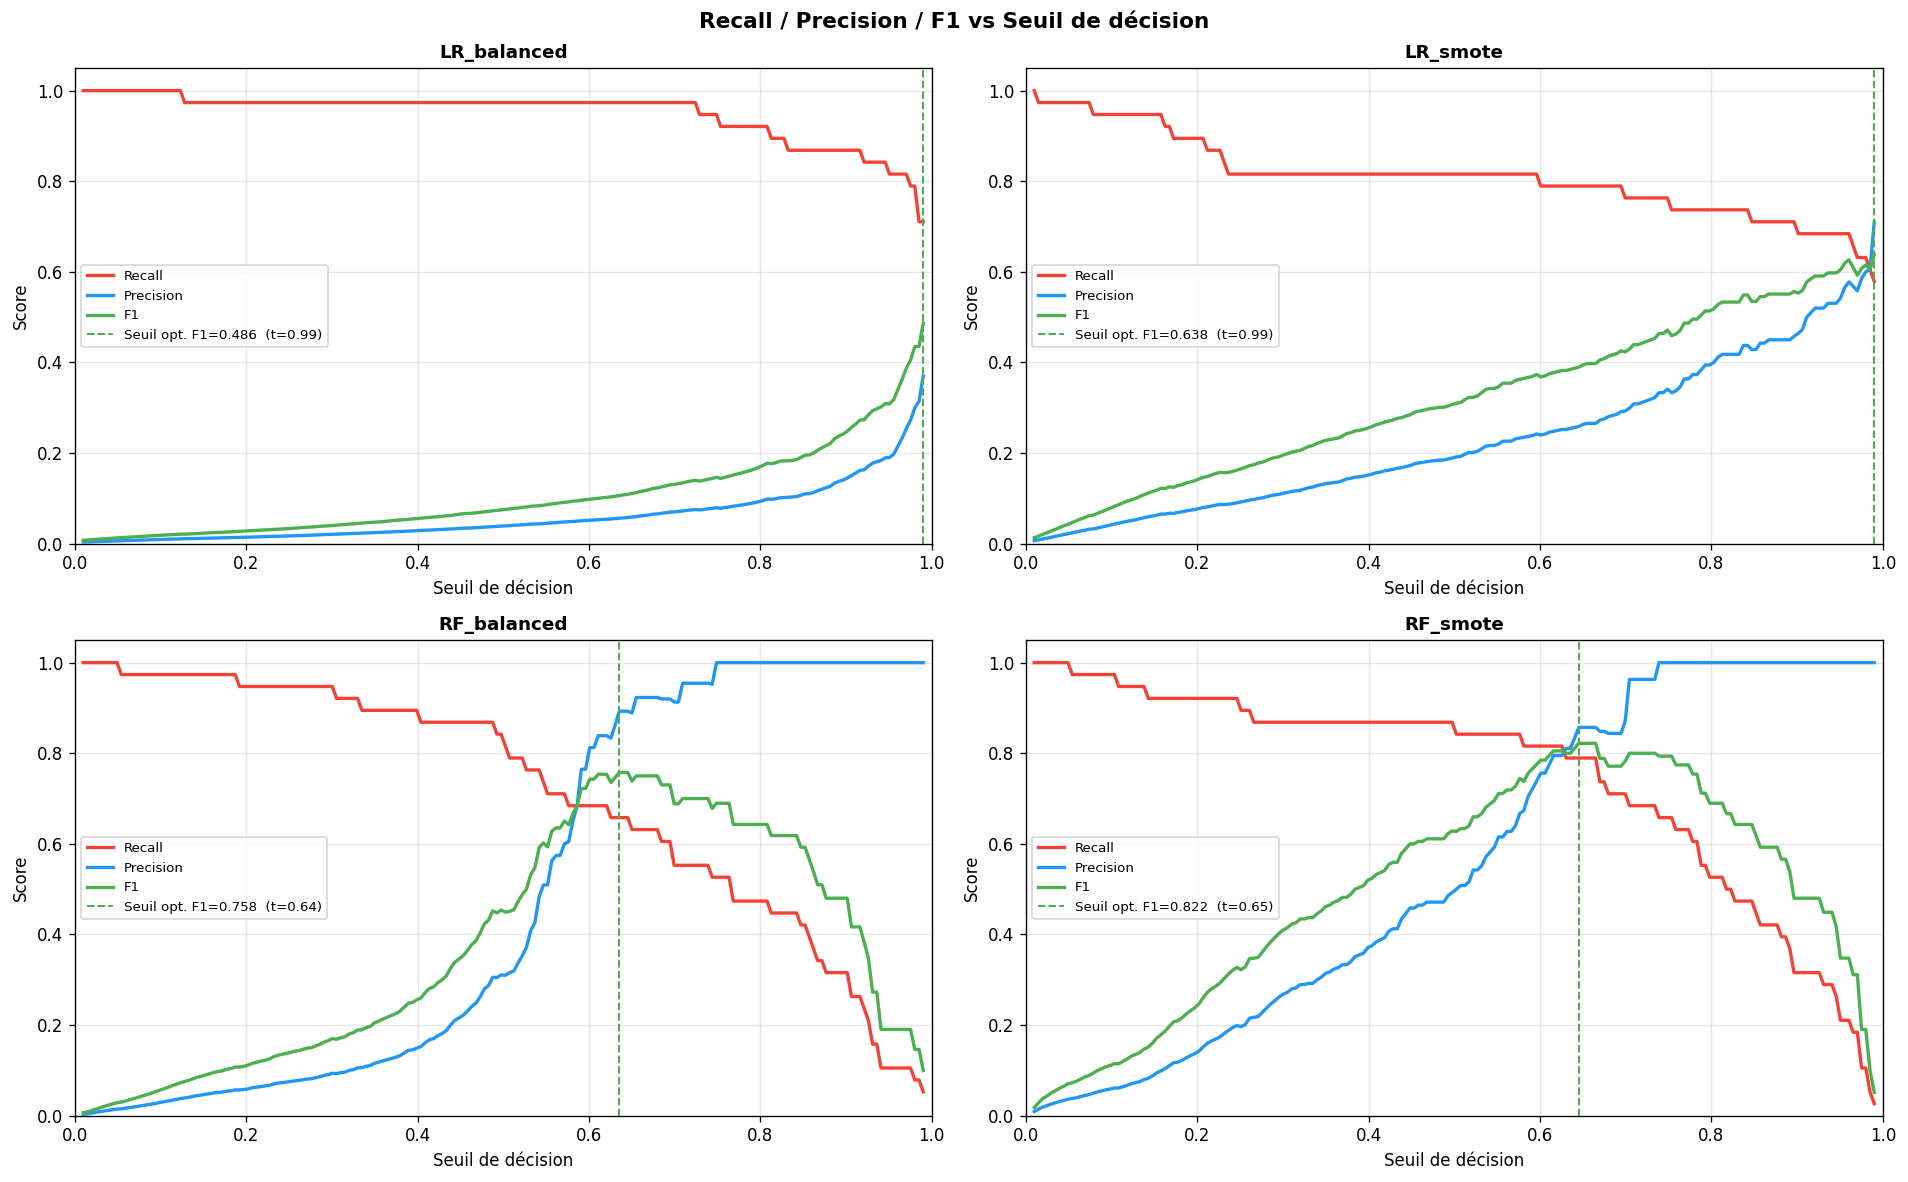

In [17]:
# — Figure 16 : Recall/Precision/F1 vs seuil —
plot_threshold_analysis(
    models_val_scores,
    save_path=FIGURES_DIR / '16_threshold_analysis.png'
)
plt.show()


---
### 8. Comparaison des 4 modèles

Comparaison sur le **test set** avec seuil optimal (séctionné val).
Mériques prioritaires : **Recall** Â· **PR-AUC** Â· **F1**


In [18]:
# Collecte des méiques test (seuil optimal)
all_metrics_test = list(metrics_opt.values())

df_comparison = compare_models(all_metrics_test)
print('Classement par Recall déroissant :')
print(df_comparison[['model','recall','precision','f1','pr_auc','roc_auc','tp','fn']].to_string(index=False))


Classement par Recall déroissant :
               model  recall  precision     f1  pr_auc  roc_auc  tp  fn
   RF_smote (t=0.63)  0.7949     0.8158 0.8052  0.8405   0.9940  31   8
RF_balanced (t=0.62)  0.7692     0.8333 0.8000  0.7794   0.9922  30   9
   LR_smote (t=0.96)  0.6923     0.7297 0.7105  0.7393   0.9949  27  12
LR_balanced (t=1.00)  0.6410     0.6579 0.6494  0.7044   0.9961  25  14


Figure sauvegardée : 12_pr_curves.png


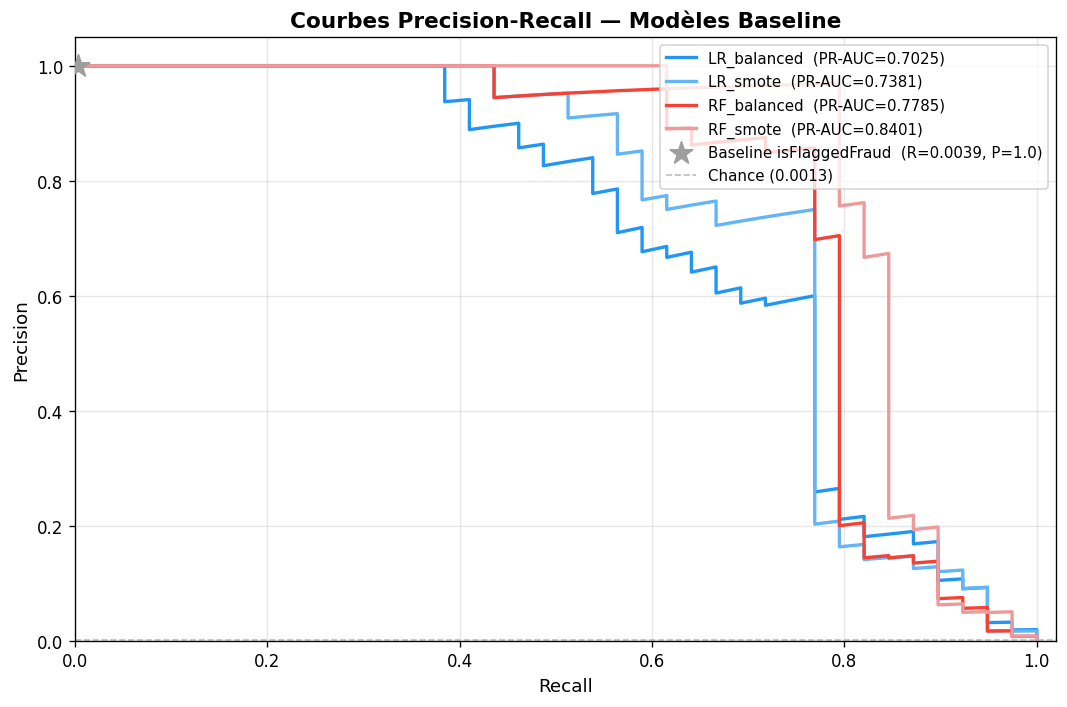

In [19]:
# — Figure 12 : Courbes PR —
pr_input = {
    'LR_balanced': (np.asarray(y_test), lr_bal_score_test),
    'LR_smote':    (np.asarray(y_test), lr_smote_score_test),
    'RF_balanced': (np.asarray(y_test), rf_bal_score_test),
    'RF_smote':    (np.asarray(y_test), rf_smote_score_test),
}
plot_pr_curves(pr_input, save_path=FIGURES_DIR / '12_pr_curves.png')
plt.show()


Figure sauvegardée : 13_roc_curves.png


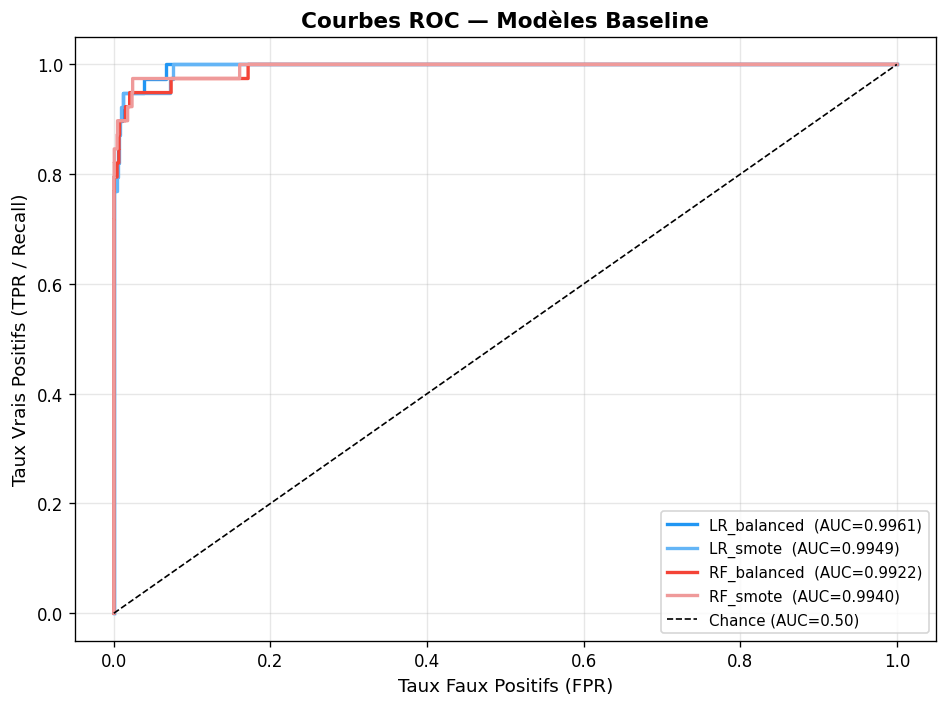

In [20]:
# — Figure 13 : Courbes ROC —
plot_roc_curves(pr_input, save_path=FIGURES_DIR / '13_roc_curves.png')
plt.show()


Figure sauvegardée : 14_confusion_matrices.png


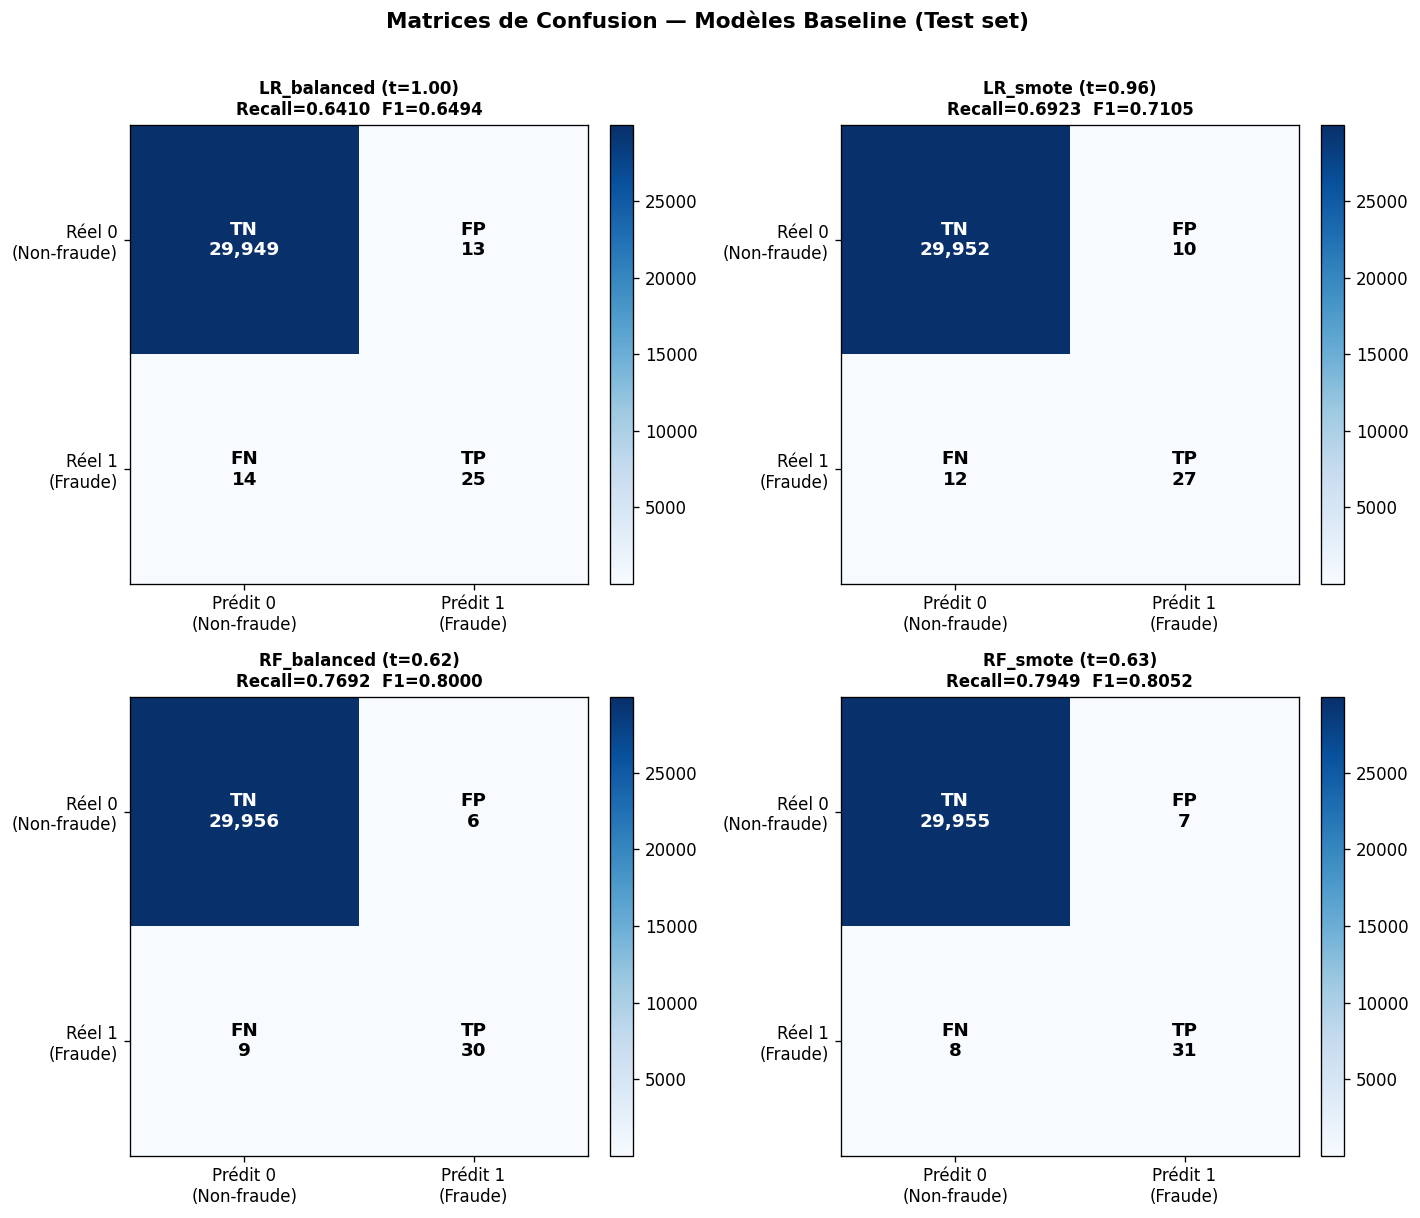

In [21]:
# — Figure 14 : Matrices de confusion —
plot_confusion_matrices(
    {m['model']: m for m in all_metrics_test},
    save_path=FIGURES_DIR / '14_confusion_matrices.png'
)
plt.show()


Figure sauvegardée : 17_model_comparison.png


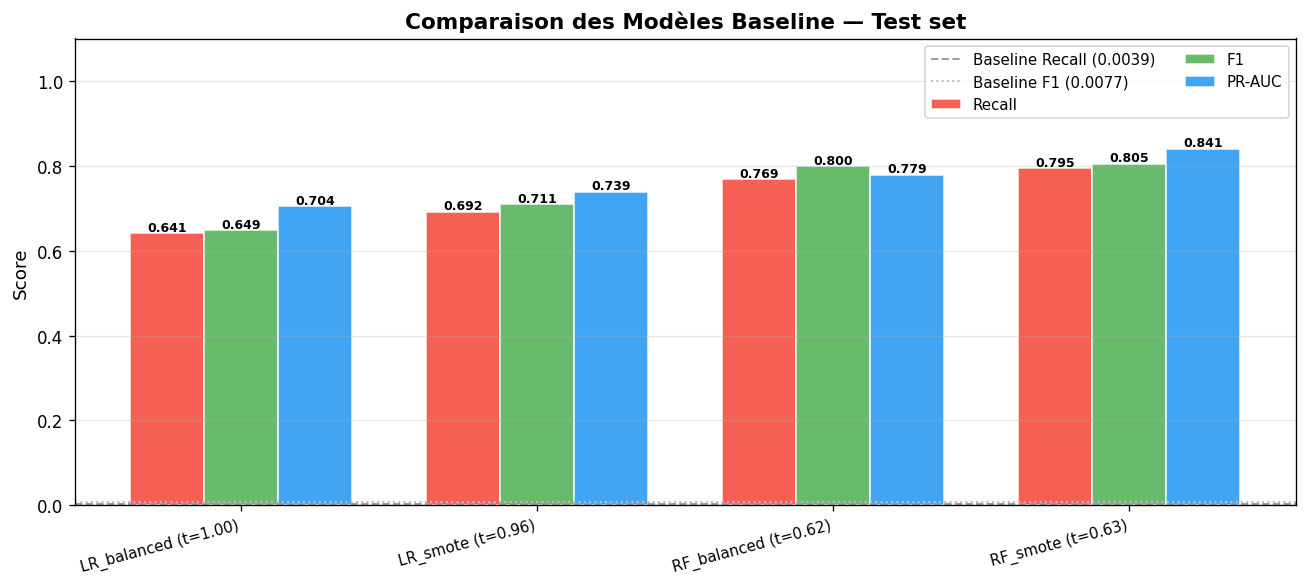

In [22]:
# — Figure 17 : Comparaison récapitulative —
plot_model_comparison(all_metrics_test,
                      save_path=FIGURES_DIR / '17_model_comparison.png')
plt.show()


---
### 9. Feature Importances (Random Forest)

Le RF fournit des importances de features basées sur la réduction
d'impuretéGini. UtilisÃé pour :
- Confirmer que les features de l'EDA (signal fort) sont bien exploité
- Identifier d'étuelles features inutiles Ã  supprimer en NB04

Rappel EDA : `balance_diff_orig` (corr=0.3662) et `dest_zero_balance`
(corr=0.1088) doivent dominer.


In [23]:
# RF_balanced —mportances
imp_bal = rf_balanced.get_feature_importances()
print('Feature Importances —F_balanced :')
print(imp_bal.to_string(index=False))


Feature Importances —F_balanced :
               feature  importance
     balance_diff_orig    0.369885
is_transfer_or_cashout    0.117091
     dest_zero_balance    0.115241
            log_amount    0.096474
                  hour    0.073681
                  step    0.055204
         type_TRANSFER    0.044972
                   day    0.038920
        high_risk_hour    0.024109
          type_PAYMENT    0.023579
         type_CASH_OUT    0.023464
                  week    0.009799
          type_CASH_IN    0.007507
            type_DEBIT    0.000073


In [24]:
# RF_smote — importances
imp_smote = rf_smote.get_feature_importances()
print('Feature Importances — RF_smote :')
print(imp_smote.to_string(index=False))


Feature Importances — RF_smote :
               feature  importance
     balance_diff_orig    0.384982
                  hour    0.117554
     dest_zero_balance    0.115331
         type_TRANSFER    0.089229
            log_amount    0.080794
                   day    0.053394
         type_CASH_OUT    0.045711
                  step    0.036341
is_transfer_or_cashout    0.031299
                  week    0.017470
          type_CASH_IN    0.011232
        high_risk_hour    0.009631
          type_PAYMENT    0.007007
            type_DEBIT    0.000024


Figure sauvegardée : 15_feature_importances.png


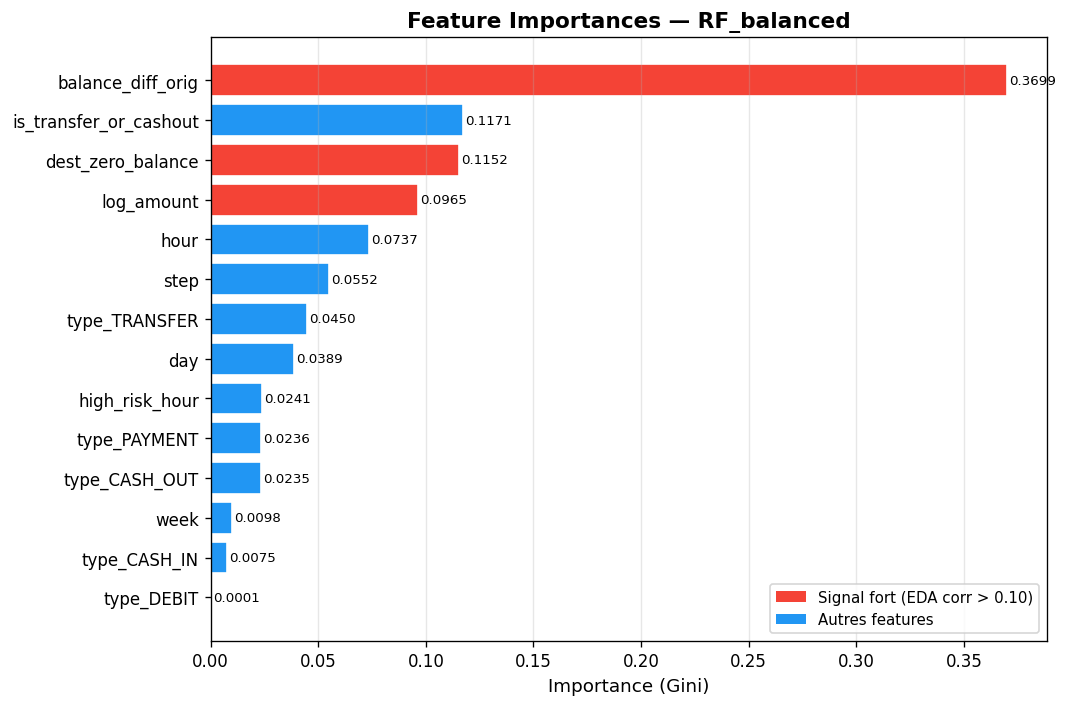

In [25]:
# — Figure 15 : Feature Importances RF_balanced —
plot_feature_importances(
    imp_bal, model_name='RF_balanced',
    save_path=FIGURES_DIR / '15_feature_importances.png'
)
plt.show()


---
### 10. Sauvegarde des modèles et rapport


In [26]:
# — Modèles .pkl —
lr_balanced.save(MODELS_DIR / 'lr_balanced.pkl')
lr_smote.save(   MODELS_DIR / 'lr_smote.pkl')
rf_balanced.save(MODELS_DIR / 'rf_balanced.pkl')
rf_smote.save(   MODELS_DIR / 'rf_smote.pkl')
print('Modèles sauvegardé :')
for name in ['lr_balanced','lr_smote','rf_balanced','rf_smote']:
    p = MODELS_DIR / f'{name}.pkl'
    print(f'  âœ… {p.name}  ({p.stat().st_size/1024:.0f} Ko)')


Modèles sauvegardé :
  âœ… lr_balanced.pkl  (2 Ko)
  âœ… lr_smote.pkl  (2 Ko)
  âœ… rf_balanced.pkl  (3216 Ko)
  âœ… rf_smote.pkl  (6023 Ko)


In [27]:
# — baseline_report.json —
baseline_report = {
    'baseline_metier': {
        'model':     'isFlaggedFraud',
        'recall':    BASELINE_RECALL,
        'precision': BASELINE_PRECISION,
        'f1':        BASELINE_F1,
    },
    'models': [
        {
            'name':              name,
            'optimal_threshold': optimal_thresholds[name],
            'train_time_s':      model.train_time,
            'test_metrics':      metrics_opt[name],
        }
        for name, model in [
            ('LR_balanced', lr_balanced),
            ('LR_smote',    lr_smote),
            ('RF_balanced', rf_balanced),
            ('RF_smote',    rf_smote),
        ]
    ],
    'best_model_recall': df_comparison.iloc[0]['model'],
    'best_model_f1':     df_comparison.sort_values('f1', ascending=False).iloc[0]['model'],
    'feature_importances_rf_balanced': imp_bal.to_dict(orient='records'),
}

with open(REPORTS_DIR / 'baseline_report.json', 'w', encoding='utf-8') as f:
    json.dump(baseline_report, f, indent=2, ensure_ascii=False)

print('âœ… baseline_report.json sauvegardé')
print(f'   Meilleur Recall : {baseline_report["best_model_recall"]}')
print(f'   Meilleur F1     : {baseline_report["best_model_f1"]}')


âœ… baseline_report.json sauvegardé
   Meilleur Recall : RF_smote (t=0.63)
   Meilleur F1     : RF_smote (t=0.63)


In [28]:
# — optimal_thresholds.json —
with open(MODELS_DIR / 'optimal_thresholds.json', 'w', encoding='utf-8') as f:
    json.dump(optimal_thresholds, f, indent=2)
print('âœ… optimal_thresholds.json sauvegardé')
print(f'   {optimal_thresholds}')


âœ… optimal_thresholds.json sauvegardé
   {'LR_balanced': 0.9986295872338673, 'LR_smote': 0.9621257303377755, 'RF_balanced': 0.6234509387008316, 'RF_smote': 0.6291040362527268}


---
## Synthèse — Modèles Baseline

### Ce que les baselines établissent

| Modèle | Stratéie imbalance | Points forts |
|---|---|---|
| LR_balanced | class_weight=balanced | Rapide, interpréable, linéaire |
| LR_smote    | SMOTE 1:10 | Exposition Ã  plus d'exemples de fraude |
| RF_balanced | class_weight=balanced | Non-linéire, robuste, feature importances |
| RF_smote    | SMOTE 1:10 | Souvent le meilleur baseline |

### Réfèrence pour les notebooks suivants

```python
# Charger les rèsultats baseline en NB04/NB05
import json
from pathlib import Path

MODELS = Path('../outputs/models')
with open(MODELS / 'baseline_report.json') as f:
    report = json.load(f)

# Seuils optimaux
with open(MODELS / 'optimal_thresholds.json') as f:
    thresholds = json.load(f)

# Recharger un modèle
from src.models.ml_models import FraudRandomForest
rf = FraudRandomForest.load(MODELS / 'rf_balanced.pkl')
```

### Prochaine ètape — Notebook 04 : AutoEncoder

L'AutoEncoder sera entraenè **uniquement sur `X_train_normal`** (transactions
lègitimes) en mode non-supervisè. Il dètecte les fraudes comme des anomalies
(erreur de reconstruction èlevée).

L'objectif : dépasser le **meilleur Recall** et le **meilleur PR-AUC** obtenus ici.
